# Test of Gaussian Process Inverse Methods
Newton Schulz inverse vs. Numpy Inverse vs. Cholseky

In [ ]:
import numpy as np
import os 
import matplotlib.pyplot as plt
import sys
from pathlib import Path
import GP
import inverses
REPO_ROOT = Path.cwd().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from functions import Newton_Shulz

(20,)
(20,)
Using provided initial guess for Newton-Schulz
Newton-Schulz converged at iteration 30 (error: 1.257389e-09 < 1.00e-08)
Newton_Shulz took 0.0006 seconds to execute.


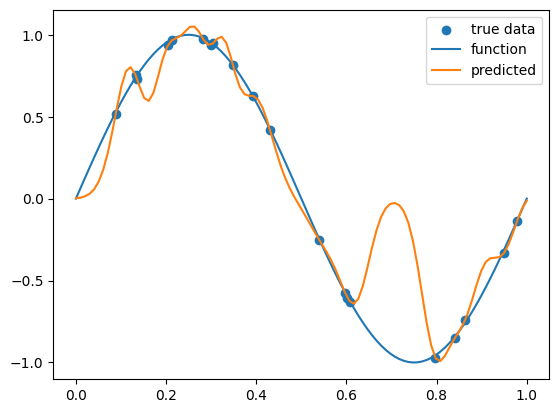

In [ ]:
# make somme data
n = 20
sig = 0.01
x = np.random.rand(n)
# print(x)
y = np.sin(x* 2*np.pi) + sig*np.random.randn(n)

print(x.shape)
print(y.shape)

xth = np.linspace(0,1, 100)
yth = np.sin(xth * 2*np.pi)

# create a gaussian process object
gauss = GP.GPR(n, 1, "RBF", sig, use_ns=True, verbose=True)
# fit the gaussian process to the given data, for some sigma_f and l
gauss.fit(np.array([x]), y, theta=np.array([10, 1e-3])) # changing the hyperparameters gives you different fits
# new_x = np.random.rand(5)
new_y = gauss.predict_aft_K(xth)

fig = plt.figure()
plt.scatter(x, y, label="true data")
plt.plot(xth, yth, label="function")
plt.plot(xth, new_y, label="predicted")

plt.legend()

In [ ]:
ni = inverses.NumpyInverse(True, True)
print(gauss.ker.mat.shape)
x = ni.vecSolve(gauss.ker.mat, np.ones(20))
print(gauss.ker.mat @ x)
x2 = ni.vecSolve(gauss.ker.mat, np.ones(20))
ni.invalidateInverse()
x3 = ni.vecSolve(gauss.ker.mat, np.ones(20))

(20, 20)
Computing inverse via numpy
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Computing inverse via numpy


In [4]:
# try optimizing
gauss.grad_dec_theta(np.array([1, 1]), alpha=1e-5)
new_y = gauss.predict_aft_K(xth)

fig = plt.figure()
plt.scatter(x, y, label="true data")
plt.plot(xth, yth, label="function")
plt.plot(xth, new_y, label="predicted")

plt.legend()

Running gradient descent with theta0 = [1 1]
Using a stopping condition of ||nabla f||^2 < 1e-05
Using a step size of 1e-05
Using provided initial guess for Newton-Schulz
Newton_Shulz exceeded the max number of iterations and has error 4.618221991874798e-07
Newton_Shulz took 0.0381 seconds to execute.
Iteration 0
theta =  [1 1]
log liklihood = -1647.0968520065298
Iteration 1
theta =  [27.76756642  0.97858221]
Using provided initial guess for Newton-Schulz
Newton_Shulz exceeded the max number of iterations and has error 0.269993347666903
Newton_Shulz took 0.0609 seconds to execute.
log liklihood = -14.252244564807391
Iteration 2
theta =  [126.59601754   0.97814563]
Using provided initial guess for Newton-Schulz
Newton_Shulz exceeded the max number of iterations and has error 136.58649696853965
Newton_Shulz took 0.0551 seconds to execute.
log liklihood = 17.89550300589387
Iteration 3
theta =  [171.4774823    0.97799889]
Using provided initial guess for Newton-Schulz
Newton_Shulz exceeded

/home/trevor/Documents/School/Grad_school/research/Newton_shulz/Newton_Shulz/gauss_proc/GP.py:209: RuntimeWarning: logm result may be inaccurate, approximate err = 2.348330503209597e-13
  logKhat = scil.logm(Khat)
/home/trevor/Documents/School/Grad_school/research/Newton_shulz/Newton_Shulz/gauss_proc/GP.py:209: RuntimeWarning: logm result may be inaccurate, approximate err = 8.280649919943448e-13
  logKhat = scil.logm(Khat)


Newton_Shulz exceeded the max number of iterations and has error 4.358898943540672
Newton_Shulz took 0.0846 seconds to execute.


/home/trevor/Documents/School/Grad_school/research/Newton_shulz/Newton_Shulz/.env/lib/python3.10/site-packages/scipy/linalg/_matfuncs.py:202: LogmExactlySingularWarning: The logm input matrix is exactly singular.
  F = scipy.linalg._matfuncs_inv_ssq._logm(A)
/home/trevor/Documents/School/Grad_school/research/Newton_shulz/Newton_Shulz/.env/lib/python3.10/site-packages/scipy/linalg/_matfuncs.py:373: RuntimeWarning: overflow encountered in matmul
  eAw = eAw @ eAw

KeyboardInterrupt



In [ ]:
# create a gaussian process object
gauss_no_ns = GP.GPR(n, 1, "RBF", sig, use_ns=False, verbose=True)
# fit the gaussian process to the given data, for some sigma_f and l
gauss_no_ns.fit(np.array([x]), y, theta=np.array([10, 1e-3])) # changing the hyperparameters gives you different fits
# new_x = np.random.rand(5)
new_y = gauss_no_ns.predict_aft_K(xth)

In [ ]:
# try optimizing
gauss_no_ns.grad_dec_theta(np.array([1, 1]), alpha=1e-5)
new_y = gauss_no_ns.predict_aft_K(xth)

fig = plt.figure()
plt.scatter(x, y, label="true data")
plt.plot(xth, yth, label="function")
plt.plot(xth, new_y, label="predicted")

plt.legend()

Running gradient descent with theta0 = [1 1]
Using a stopping condition of ||nabla f||^2 < 1e-05
Using a step size of 1e-05
Iteration 0
theta =  [1 1]
log liklihood = -1736.2853938448663
Iteration 1
theta =  [42.82477856  0.97921211]
log liklihood = 0.4240177403501022
Iteration 2
theta =  [123.50382021   0.97881149]
log liklihood = 18.296195269316613
Iteration 3
theta =  [168.35044208   0.97867907]
log liklihood = 19.527268788694812
Iteration 4
theta =  [218.9465155    0.97862032]
log liklihood = 19.566414721606428
Iteration 5
theta =  [279.96144291   0.97858443]
log liklihood = 19.045423263239513
Iteration 6
theta =  [354.9035947    0.97858527]
log liklihood = 18.202389019587905
Iteration 7
theta =  [447.40805141   0.97849569]
log liklihood = 17.15954932188994
Iteration 8
theta =  [561.92799361   0.97830905]
log liklihood = 15.982132286046983
Iteration 9
theta =  [704.36857398   0.97859515]
log liklihood = 14.707213550806635
Iteration 10
theta =  [882.59992579   0.97935602]
log liklih

/home/trevor/Documents/School/Grad_school/research/Newton_shulz/Newton_Shulz/gauss_proc/GP.py:209: RuntimeWarning: logm result may be inaccurate, approximate err = 6.631520139596099e-13
  logKhat = scil.logm(Khat)


LinAlgError: Singular matrix